# Unit06 線性聯立方程式之求解

## 學習目標

在本單元中，我們將學習如何使用 Python 的 NumPy 和 SciPy 套件來求解線性聯立方程式系統。這些技術在化工領域中有廣泛的應用，包括物料平衡、能量平衡、反應器網絡分析等問題。

學習完本單元後，您將能夠：

- 理解線性聯立方程式的數學基礎與解的存在性條件
- 使用 NumPy 的線性代數工具進行基本的矩陣運算與求解
- 運用 SciPy 的進階求解器處理各種類型的線性系統
- 分析並處理不同類型的線性系統（唯一解、無窮多解、無解、病態系統）
- 將線性方程式求解技術應用於實際化工問題
- 撰寫穩健的程式碼並進行結果驗證

## 內容大綱

本 Notebook 包含以下內容：

0. 環境設定與套件載入
2. NumPy 線性代數基礎工具
3. SciPy 進階求解方法
4. 不同系統類型的處理策略
5. 化工問題中的應用
6. 程式設計最佳實踐
7. 總結

---
## 0. 環境設定與套件載入

在開始之前，我們需要載入必要的 Python 套件，包括 NumPy（線性代數運算）、SciPy（進階數值方法）和 Matplotlib（資料視覺化）。

In [1]:
# 基礎套件
import numpy as np
import matplotlib.pyplot as plt

# SciPy 線性代數模組
from scipy import linalg
from scipy.sparse import csr_matrix, lil_matrix, diags
from scipy.sparse.linalg import spsolve, cg, gmres

# 設定 NumPy 顯示選項
np.set_printoptions(precision=4, suppress=True)

# 設定 Matplotlib 繪圖樣式
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.unicode_minus'] = False  # 修正負號顯示

print("="*60)
print("套件載入完成！")
print("="*60)
print(f"NumPy version: {np.__version__}")
import scipy
print(f"SciPy version: {scipy.__version__}")
print("="*60)

套件載入完成！
NumPy version: 1.23.5
SciPy version: 1.15.2


---
## 2. NumPy 線性代數基礎工具

NumPy 的 `numpy.linalg` 子模組提供了一系列線性代數運算工具。在本節中，我們將示範最常用的 6 個函數。

### 2.1 計算矩陣秩與行列式

首先建立測試矩陣，並計算其秩 (rank) 與行列式 (determinant)。

In [2]:
# 建立測試矩陣 A1（秩不滿）
A1 = np.array([[1, 2, 3],
               [2, 4, 6],
               [1, 1, 1]])

print("矩陣 A1:")
print(A1)
print(f"\nRank of A1: {np.linalg.matrix_rank(A1)}")
print(f"Determinant of A1: {np.linalg.det(A1):.4f}")

# 建立可逆矩陣 A2
A2 = np.array([[2, 1],
               [1, 3]])

print("\n" + "="*50)
print("矩陣 A2:")
print(A2)
print(f"\nRank of A2: {np.linalg.matrix_rank(A2)}")
print(f"Determinant of A2: {np.linalg.det(A2):.4f}")

if np.linalg.det(A2) != 0:
    print("\n✓ Matrix A2 is invertible (det ≠ 0)")
else:
    print("\n✗ Matrix A2 is singular (det = 0)")

矩陣 A1:
[[1 2 3]
 [2 4 6]
 [1 1 1]]

Rank of A1: 2
Determinant of A1: 0.0000

矩陣 A2:
[[2 1]
 [1 3]]

Rank of A2: 2
Determinant of A2: 5.0000

✓ Matrix A2 is invertible (det ≠ 0)


### 2.2 求解唯一解系統 - np.linalg.solve()

求解線性方程組 $\mathbf{Ax} = \mathbf{b}$ ，其中 $\mathbf{A}$ 為可逆方陣。

**範例**：求解 $2x_1 + x_2 = 5$ ， $x_1 + 3x_2 = 6$

In [3]:
# 求解 2x + y = 5, x + 3y = 6
A = np.array([[2, 1],
              [1, 3]])
b = np.array([5, 6])

print("求解線性方程組 Ax = b")
print("\nA =")
print(A)
print("\nb =", b)

# 求解
x = np.linalg.solve(A, b)
print("\n解 x =", x)

# 驗證解的正確性
residual = A @ x - b
residual_norm = np.linalg.norm(residual)
print(f"\n驗證（殘差範數）: {residual_norm:.2e}")

# 代回驗證
print("\n代回驗證:")
print(f"A @ x = {A @ x}")
print(f"b     = {b}")

if residual_norm < 1e-10:
    print("\n✓ 解正確！")

求解線性方程組 Ax = b

A =
[[2 1]
 [1 3]]

b = [5 6]

解 x = [1.8 1.4]

驗證（殘差範數）: 0.00e+00

代回驗證:
A @ x = [5. 6.]
b     = [5 6]

✓ 解正確！


### 2.3 最小平方解 - np.linalg.lstsq()

處理過確定系統（方程式數 > 未知數數），求解使殘差 $\|\mathbf{Ax} - \mathbf{b}\|^2$ 最小的解。

**範例**：直線擬合 $y = a + bx$

過確定系統：擬合直線 y = a + b*x

數據點數: 4
未知數數: 2 (a, b)

A (Design Matrix) =
[[1 1]
 [1 2]
 [1 3]
 [1 4]]

b (y_data) = [2.1 3.9 6.2 7.8]

最小平方解:
a (intercept) = 0.1500
b (slope)     = 1.9400

擬合方程式: y = 0.1500 + 1.9400 * x
殘差平方和: 8.2000e-02
RMS error: 1.4318e-01


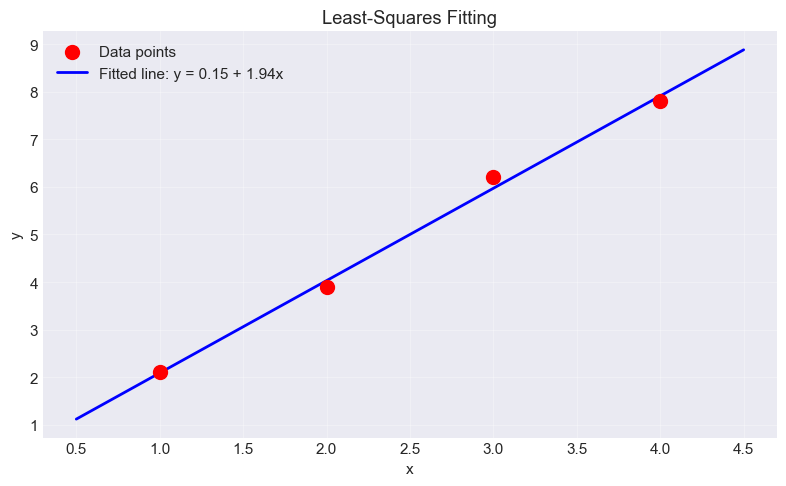

In [4]:
# 範例：4 個數據點，擬合直線 y = a + b*x
x_data = np.array([1, 2, 3, 4])
y_data = np.array([2.1, 3.9, 6.2, 7.8])

# 建立設計矩陣（Design Matrix）
# [1, x1]
# [1, x2]
# ...
A_fit = np.column_stack([np.ones_like(x_data), x_data])

print("過確定系統：擬合直線 y = a + b*x")
print(f"\n數據點數: {len(x_data)}")
print(f"未知數數: 2 (a, b)")
print("\nA (Design Matrix) =")
print(A_fit)
print("\nb (y_data) =", y_data)

# 求最小平方解
result = np.linalg.lstsq(A_fit, y_data, rcond=None)
coeffs = result[0]
residual_sum_sq = result[1][0] if len(result[1]) > 0 else 0

a, b = coeffs
print(f"\n最小平方解:")
print(f"a (intercept) = {a:.4f}")
print(f"b (slope)     = {b:.4f}")
print(f"\n擬合方程式: y = {a:.4f} + {b:.4f} * x")
print(f"殘差平方和: {residual_sum_sq:.4e}")
print(f"RMS error: {np.sqrt(residual_sum_sq/len(x_data)):.4e}")

# 繪製擬合結果
plt.figure(figsize=(8, 5))
plt.scatter(x_data, y_data, s=100, color='red', label='Data points', zorder=3)
x_line = np.linspace(0.5, 4.5, 100)
y_line = a + b * x_line
plt.plot(x_line, y_line, 'b-', linewidth=2, label=f'Fitted line: y = {a:.2f} + {b:.2f}x')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Least-Squares Fitting')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.4 虛擬反矩陣 - np.linalg.pinv()

計算 Moore-Penrose 虛擬反矩陣，適用於低確定系統（未知數數 > 方程式數）。

**範例**：求解 $x_1 + 2x_2 + 3x_3 = 6$ （1 個方程式，3 個未知數）

In [5]:
# 低確定系統：1 個方程式，3 個未知數
# x1 + 2*x2 + 3*x3 = 6
A_under = np.array([[1, 2, 3]])
b_under = np.array([6])

print("低確定系統: x1 + 2*x2 + 3*x3 = 6")
print("\nA =", A_under)
print("b =", b_under)

# 計算虛擬反矩陣
A_pinv = np.linalg.pinv(A_under)
x_min_norm = A_pinv @ b_under

print("\n最小範數解（距離原點最近）:")
print(f"x = {x_min_norm}")
print(f"範數 ||x|| = {np.linalg.norm(x_min_norm):.4f}")

# 驗證解
verification = A_under @ x_min_norm
print(f"\n驗證: A @ x = {verification}")
print(f"應等於 b = {b_under}")

if np.allclose(verification, b_under):
    print("\n✓ 解滿足方程式")

低確定系統: x1 + 2*x2 + 3*x3 = 6

A = [[1 2 3]]
b = [6]

最小範數解（距離原點最近）:
x = [0.4286 0.8571 1.2857]
範數 ||x|| = 1.6036

驗證: A @ x = [6.]
應等於 b = [6]

✓ 解滿足方程式


### 2.5 條件數檢查 - np.linalg.cond()

**條件數** (condition number) 衡量矩陣的數值穩定性。條件數越大，系統越容易受到數值誤差影響。

一般而言：
- $\kappa < 10^3$ ：穩定系統
- $10^3 \leq \kappa < 10^6$ ：稍微病態
- $\kappa \geq 10^6$ ：病態系統 (ill-conditioned)

In [6]:
# 測試不同條件數的矩陣

# 穩定矩陣
A_stable = np.array([[4, 1],
                     [1, 3]])
cond_stable = np.linalg.cond(A_stable)

print("穩定矩陣:")
print(A_stable)
print(f"條件數: {cond_stable:.2e}")
if cond_stable < 1e3:
    print("✓ 數值穩定")

# 病態矩陣（Hilbert matrix）
n = 5
A_ill = np.array([[1/(i+j+1) for j in range(n)] for i in range(n)])
cond_ill = np.linalg.cond(A_ill)

print("\n" + "="*50)
print("病態矩陣 (Hilbert Matrix):")
print(A_ill)
print(f"條件數: {cond_ill:.2e}")
if cond_ill > 1e6:
    print("⚠ 病態系統！數值不穩定")
    
print("\n建議：求解前先檢查條件數，避免數值誤差過大")

穩定矩陣:
[[4 1]
 [1 3]]
條件數: 1.94e+00
✓ 數值穩定

病態矩陣 (Hilbert Matrix):
[[1.     0.5    0.3333 0.25   0.2   ]
 [0.5    0.3333 0.25   0.2    0.1667]
 [0.3333 0.25   0.2    0.1667 0.1429]
 [0.25   0.2    0.1667 0.1429 0.125 ]
 [0.2    0.1667 0.1429 0.125  0.1111]]
條件數: 4.77e+05

建議：求解前先檢查條件數，避免數值誤差過大


---
## 5. 化工問題中的應用

線性方程式求解在化工領域有廣泛的應用。以下示範幾個典型場景。

### 5.1 物料平衡方程組 - 液體摻合問題

某工廠有三個儲存槽，欲混合成特定組成的產品。

| 槽號 | 成分 A (%) | 成分 B (%) | 成分 C (%) |
|------|-----------|-----------|-----------|
| 1 | 50 | 30 | 20 |
| 2 | 20 | 60 | 20 |
| 3 | 30 | 10 | 60 |

**目標**：混合 100 kg 產品，組成為 A: 35%、B: 35%、C: 30%。求各槽所需用量。

In [7]:
# 液體摻合問題
print("="*60)
print("液體摻合問題 - 物料平衡")
print("="*60)

# 各槽組成（體積率 %）
#       成分A  成分B  成分C
tank1 = [50,   30,    20]
tank2 = [20,   60,    20]
tank3 = [30,   10,    60]

print("\n各儲存槽組成 (%):")
print(f"槽 1: A={tank1[0]}, B={tank1[1]}, C={tank1[2]}")
print(f"槽 2: A={tank2[0]}, B={tank2[1]}, C={tank2[2]}")
print(f"槽 3: A={tank3[0]}, B={tank3[1]}, C={tank3[2]}")

# 目標產品組成
target = [35, 35, 30]  # A, B, C
total_volume = 100  # kg

print(f"\n目標產品 ({total_volume} kg):")
print(f"成分 A: {target[0]}%")
print(f"成分 B: {target[1]}%")
print(f"成分 C: {target[2]}%")

# 建立物料平衡方程式
# 成分 A: 0.50*V1 + 0.20*V2 + 0.30*V3 = 35
# 成分 B: 0.30*V1 + 0.60*V2 + 0.10*V3 = 35
# 成分 C: 0.20*V1 + 0.20*V2 + 0.60*V3 = 30
# 總量:   V1 + V2 + V3 = 100

A_blend = np.array([[0.50, 0.20, 0.30],
                    [0.30, 0.60, 0.10],
                    [0.20, 0.20, 0.60],
                    [1.00, 1.00, 1.00]])

b_blend = np.array([35, 35, 30, 100])

print("\n係數矩陣 A:")
print(A_blend)
print("\n常數向量 b:")
print(b_blend)

# 這是過確定系統（4個方程，3個未知數）
print(f"\n系統類型: 過確定系統 ({A_blend.shape[0]} 個方程式, {A_blend.shape[1]} 個未知數)")

# 使用最小平方法求解
V_tanks, residuals = np.linalg.lstsq(A_blend, b_blend, rcond=None)[:2]

print("\n各槽所需用量:")
print(f"槽 1: {V_tanks[0]:.2f} kg")
print(f"槽 2: {V_tanks[1]:.2f} kg")
print(f"槽 3: {V_tanks[2]:.2f} kg")
print(f"總計: {V_tanks.sum():.2f} kg")

# 驗證質量守恆
if len(residuals) > 0:
    print(f"\n殘差平方和: {residuals[0]:.2e}")
    if residuals[0] < 1e-6:
        print("✓ 物料平衡滿足")

# 驗證成分組成
actual_composition = A_blend[:3] @ V_tanks
print("\n實際得到的組成:")
print(f"成分 A: {actual_composition[0]:.2f}")
print(f"成分 B: {actual_composition[1]:.2f}")
print(f"成分 C: {actual_composition[2]:.2f}")

液體摻合問題 - 物料平衡

各儲存槽組成 (%):
槽 1: A=50, B=30, C=20
槽 2: A=20, B=60, C=20
槽 3: A=30, B=10, C=60

目標產品 (100 kg):
成分 A: 35%
成分 B: 35%
成分 C: 30%

係數矩陣 A:
[[0.5 0.2 0.3]
 [0.3 0.6 0.1]
 [0.2 0.2 0.6]
 [1.  1.  1. ]]

常數向量 b:
[ 35  35  30 100]

系統類型: 過確定系統 (4 個方程式, 3 個未知數)

各槽所需用量:
槽 1: 41.67 kg
槽 2: 33.33 kg
槽 3: 25.00 kg
總計: 100.00 kg

殘差平方和: 1.54e-30
✓ 物料平衡滿足

實際得到的組成:
成分 A: 35.00
成分 B: 35.00
成分 C: 30.00


### 5.2 反應器網絡分析 - 串聯 CSTR

三個串聯的連續攪拌槽反應器 (CSTR)，反應為 $\mathrm{A} \rightarrow \mathrm{B}$ （一階反應）。

求解穩態時各反應器的出口濃度。

CSTR 反應器網絡 - 串聯反應器穩態分析

操作參數:
進料流率 F0 = 100 L/min
進料濃度 CA0 = 2.0 mol/L
反應速率常數 k = 0.5 1/min
反應器體積 V = 50 L (各反應器)

物料平衡方程組:
A =
[[ 125.    0.    0.]
 [-100.  125.    0.]
 [   0. -100.  125.]]

b = [200.   0.   0.]

各反應器出口濃度:
Reactor 1: CA = 1.6000 mol/L
Reactor 2: CA = 1.2800 mol/L
Reactor 3: CA = 1.0240 mol/L

轉化率:
Reactor 1: 20.00%
Reactor 2: 36.00%
Reactor 3: 48.80%

總轉化率: 48.80%


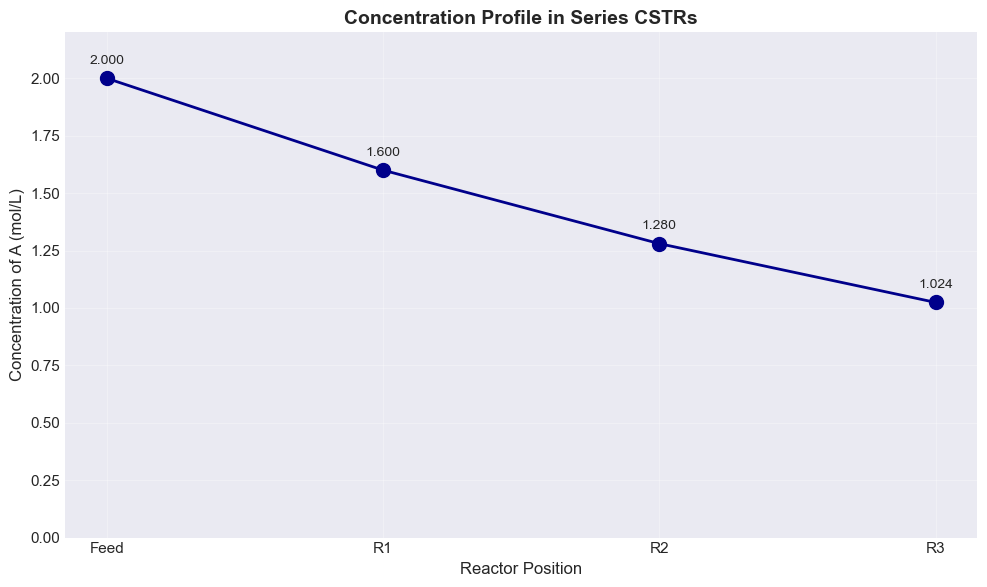


✓ 濃度分布圖已繪製


In [8]:
# CSTR 反應器網絡分析
print("="*60)
print("CSTR 反應器網絡 - 串聯反應器穩態分析")
print("="*60)

# 參數設定
F0 = 100    # 進料流率 (L/min)
CA0 = 2.0   # 進料濃度 (mol/L)
k = 0.5     # 反應速率常數 (1/min)
V1 = V2 = V3 = 50  # 各反應器體積 (L)

print(f"\n操作參數:")
print(f"進料流率 F0 = {F0} L/min")
print(f"進料濃度 CA0 = {CA0} mol/L")
print(f"反應速率常數 k = {k} 1/min")
print(f"反應器體積 V = {V1} L (各反應器)")

# 穩態物料平衡（假設流率不變）
# Reactor 1: (F + V*k)*CA1 = F*CA0
# Reactor 2: (F + V*k)*CA2 = F*CA1
# Reactor 3: (F + V*k)*CA3 = F*CA2

F = F0
A_reactor = np.array([[F + V1*k, 0, 0],
                      [-F, F + V2*k, 0],
                      [0, -F, F + V3*k]])

b_reactor = np.array([F*CA0, 0, 0])

print("\n物料平衡方程組:")
print("A =")
print(A_reactor)
print("\nb =", b_reactor)

# 求解
C = np.linalg.solve(A_reactor, b_reactor)

print("\n各反應器出口濃度:")
print(f"Reactor 1: CA = {C[0]:.4f} mol/L")
print(f"Reactor 2: CA = {C[1]:.4f} mol/L")
print(f"Reactor 3: CA = {C[2]:.4f} mol/L")

# 計算轉化率
conversion = (CA0 - C) / CA0 * 100
overall_conversion = (CA0 - C[2]) / CA0 * 100

print("\n轉化率:")
print(f"Reactor 1: {conversion[0]:.2f}%")
print(f"Reactor 2: {conversion[1]:.2f}%")
print(f"Reactor 3: {conversion[2]:.2f}%")
print(f"\n總轉化率: {overall_conversion:.2f}%")

# 繪製濃度分布
reactors = ['Feed', 'R1', 'R2', 'R3']
concentrations = [CA0] + C.tolist()

plt.figure(figsize=(10, 6))
plt.plot(reactors, concentrations, 'o-', linewidth=2, markersize=10, color='darkblue')
plt.xlabel('Reactor Position', fontsize=12)
plt.ylabel('Concentration of A (mol/L)', fontsize=12)
plt.title('Concentration Profile in Series CSTRs', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.ylim(0, CA0*1.1)
for i, (r, c) in enumerate(zip(reactors, concentrations)):
    plt.text(i, c+0.05, f'{c:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print("\n✓ 濃度分布圖已繪製")

---
## 6. 程式設計最佳實踐

建立一個完整的線性方程組求解器類別，包含診斷、求解、驗證功能。

### 6.1 LinearSystemSolver 類別定義

In [9]:
class LinearSystemSolver:
    """線性方程組求解器類別，包含完整診斷、求解、驗證功能"""
    
    def __init__(self, A, b, name="System"):
        """
        初始化求解器
        
        Parameters:
        -----------
        A : array_like
            係數矩陣
        b : array_like
            常數向量
        name : str
            系統名稱（用於診斷輸出）
        """
        self.name = name
        self.A = np.asarray(A, dtype=float)
        self.b = np.asarray(b, dtype=float)
        self.x = None
        self.diagnostics = {}
        
    def diagnose(self):
        """診斷系統特性"""
        print(f"\n{'='*50}")
        print(f"Diagnosing: {self.name}")
        print(f"{'='*50}")
        
        m, n = self.A.shape
        print(f"Matrix size: {m} × {n}")
        print(f"Number of equations: {m}")
        print(f"Number of unknowns: {n}")
        
        # 檢查秩
        rank_A = np.linalg.matrix_rank(self.A)
        rank_Ab = np.linalg.matrix_rank(np.column_stack([self.A, self.b]))
        print(f"Rank of A: {rank_A}")
        print(f"Rank of [A|b]: {rank_Ab}")
        
        # 檢查行列式（方陣）
        if m == n:
            det_A = np.linalg.det(self.A)
            print(f"Determinant: {det_A:.2e}")
            
            if abs(det_A) < 1e-10:
                print("⚠ Matrix is nearly singular")
            
            # 條件數
            if rank_A == n:
                cond = np.linalg.cond(self.A)
                print(f"Condition number: {cond:.2e}")
                
                if cond > 1e10:
                    print("⚠ System is ill-conditioned")
        
        # 檢查對稱性
        if m == n:
            is_symmetric = np.allclose(self.A, self.A.T)
            print(f"Symmetric: {is_symmetric}")
        
        return rank_A, rank_Ab
    
    def solve(self, method='auto', verbose=True):
        """
        求解系統
        
        Parameters:
        -----------
        method : str
            求解方法 ('auto', 'solve', 'lstsq', 'pinv')
        verbose : bool
            是否顯示詳細資訊
            
        Returns:
        --------
        x : ndarray
            解向量
        """
        try:
            rank_A, rank_Ab = self.diagnose() if verbose else (
                np.linalg.matrix_rank(self.A),
                np.linalg.matrix_rank(np.column_stack([self.A, self.b]))
            )
            
            m, n = self.A.shape
            
            if rank_A < rank_Ab:
                raise ValueError("System is inconsistent (no solution)")
            
            # 選擇方法
            if method == 'auto':
                if m == n and rank_A == n:
                    self.x = np.linalg.solve(self.A, self.b)
                    method_used = 'solve'
                elif m > n:
                    self.x = np.linalg.lstsq(self.A, self.b, rcond=None)[0]
                    method_used = 'lstsq'
                else:
                    self.x = np.linalg.pinv(self.A) @ self.b
                    method_used = 'pinv'
            else:
                method_used = method
                if method == 'solve':
                    self.x = np.linalg.solve(self.A, self.b)
                elif method == 'lstsq':
                    self.x = np.linalg.lstsq(self.A, self.b, rcond=None)[0]
                elif method == 'pinv':
                    self.x = np.linalg.pinv(self.A) @ self.b
            
            if verbose:
                print(f"\n✓ Solution found using '{method_used}'")
            
            return self.x
            
        except np.linalg.LinAlgError as e:
            print(f"\n✗ Linear algebra error: {e}")
            raise
        except Exception as e:
            print(f"\n✗ Unexpected error: {e}")
            raise
    
    def verify(self, tol=1e-10):
        """
        驗證解
        
        Parameters:
        -----------
        tol : float
            容許誤差
            
        Returns:
        --------
        bool
            驗證是否通過
        """
        if self.x is None:
            print("No solution to verify")
            return False
        
        print(f"\n{'='*50}")
        print("Verification")
        print(f"{'='*50}")
        
        residual = self.A @ self.x - self.b
        res_norm = np.linalg.norm(residual)
        res_max = np.max(np.abs(residual))
        
        print(f"Residual norm (L2): {res_norm:.2e}")
        print(f"Max residual (L∞): {res_max:.2e}")
        
        if res_norm < tol:
            print("✓ Verification PASSED")
            return True
        else:
            print("✗ Verification FAILED")
            return False

print("✓ LinearSystemSolver 類別已定義")

✓ LinearSystemSolver 類別已定義


### 6.2 使用求解器類別 - 範例

測試 LinearSystemSolver 類別的功能。

In [10]:
# 測試求解器
A_test = np.array([[4, 1, 0],
                   [1, 3, 1],
                   [0, 1, 2]])
b_test = np.array([1, 2, 3])

# 建立求解器實例
solver = LinearSystemSolver(A_test, b_test, name="Chemical Process System")

# 求解
x_solution = solver.solve()

# 驗證
is_valid = solver.verify()

# 顯示最終解
print(f"\n{'='*50}")
print("最終解:")
print(f"{'='*50}")
print(f"x = {x_solution}")
print(f"驗證狀態: {'✓ 通過' if is_valid else '✗ 失敗'}")


Diagnosing: Chemical Process System
Matrix size: 3 × 3
Number of equations: 3
Number of unknowns: 3
Rank of A: 3
Rank of [A|b]: 3
Determinant: 1.80e+01
Condition number: 3.73e+00
Symmetric: True

✓ Solution found using 'solve'

Verification
Residual norm (L2): 4.44e-16
Max residual (L∞): 4.44e-16
✓ Verification PASSED

最終解:
x = [0.2222 0.1111 1.4444]
驗證狀態: ✓ 通過


---
## 7. 總結

本 Notebook 示範了線性聯立方程式求解的完整流程與在化工領域的應用。

### 重點回顧

**1. NumPy 線性代數工具**
- `np.linalg.matrix_rank()`: 計算矩陣秩數，判斷解的存在性
- `np.linalg.det()`: 計算行列式，檢查矩陣可逆性
- `np.linalg.solve()`: 求解唯一解系統（最快、最穩定）
- `np.linalg.lstsq()`: 求解過確定系統（最小平方法）
- `np.linalg.pinv()`: 求解低確定系統（最小範數解）
- `np.linalg.cond()`: 檢查條件數，評估數值穩定性

**2. 系統類型判斷**
- **唯一解系統**: $\mathrm{rank}(\mathbf{A}) = n$ ，方陣可逆
- **無窮多解系統**: $\mathrm{rank}(\mathbf{A}) < n$ ，低確定系統
- **無精確解系統**: $\mathrm{rank}(\mathbf{A}) < \mathrm{rank}([\mathbf{A}|\mathbf{b}])$ ，過確定系統
- **病態系統**: 條件數 $\kappa \geq 10^6$ ，數值不穩定

**3. 化工應用場景**
- 物料平衡方程組（液體摻合問題）
- 反應器網絡分析（串聯 CSTR）
- 能量平衡計算
- 循環流處理
- 解的物理意義驗證

**4. 程式設計最佳實踐**
- 求解前先診斷系統特性（秩、條件數）
- 根據系統類型選擇適當的求解方法
- 求解後驗證解的正確性（殘差檢查）
- 使用類別封裝常用功能
- 對病態系統使用特殊處理方法

### 工具選擇決策樹

```
系統特性                    建議工具
═══════════════════════════════════════════════════
方陣可逆 (det ≠ 0)         → np.linalg.solve()
過確定 (m > n)             → np.linalg.lstsq()
低確定 (m < n)             → np.linalg.pinv()
大型稀疏系統               → scipy.sparse.linalg
病態系統 (cond > 10⁶)      → 正規化或 SVD 方法
```

### 下一步學習

- **進階主題**: SciPy 進階求解方法（LU 分解、迭代法）
- **相關單元**: 
  - Unit 07: 非線性方程式求解
  - Unit 09: 常微分方程式求解
  - Unit 10: 優化問題

### 參考資料

1. **NumPy Documentation**  
   https://numpy.org/doc/stable/reference/routines.linalg.html

2. **SciPy Documentation**  
   https://docs.scipy.org/doc/scipy/reference/linalg.html

3. **Cutlip & Shacham (1999)**  
   *Problem Solving in Chemical Engineering with Numerical Methods*

4. **Chapra & Canale (2015)**  
   *Numerical Methods for Engineers*

---

**課程資訊**  
逢甲大學化學工程學系  
電腦在化工上之應用 (ChemE-3502)  
教師：莊曜禎 助理教授

**版權聲明**  
本教材僅供逢甲大學課程使用，未經許可不得轉載。